# Determine what the temperature and salinity units/definition are in the linearised equation of state by comparing to gsw

$T_f = \lambda_3 + \lambda_1S + \lambda_2 p$

where $p$ in dbar (presumed total incl atmospheric)

$\lambda_1 =  -0.0573$

$\lambda_2 = -7.53e-4$ $^\circ$C / dbar

$\lambda_3 =  0.0826$ $^\circ$C

We are not sure if $T$ is in conservative or in situ temp

and if $S$ is absolute or practical salinity (HJ99 and J10 suggest practical)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gsw

In [2]:
#linear EOS
def Tfreeze(S,p): # -> not sure what temp units are
    lam_1 = -0.0573 #Ckg/g (salinity) -> not sure what units are 
    lam_2 = -7.53e-4 #C/dbar (pressure)
    lam_3 = 0.0826 # offset
    return lam_3+lam_1*S+lam_2*(p-10.13) #dbar offset in gsw pressures - 
    #they are listed as "sea pressure[ dbar ]
    #( i.e. absolute pressure - 10.1325 dbar )"


In [3]:
#define an absolute salinity array
SA = np.linspace(32,35,100) #g/kg
p = 500 #dbar #change this to explore differnt pressures

In [4]:
# for each abs salt, define a in situ freezing temp,conservative freezing temp, practical salinity
t_freezing = gsw.t_freezing(SA,p,0) #in situ freezing temp 
CT_freezing = gsw.CT_freezing(SA,p,0) #conservative freezing temp 
SP = gsw.SP_from_SA(SA, p, 0, -65) #practical salinity

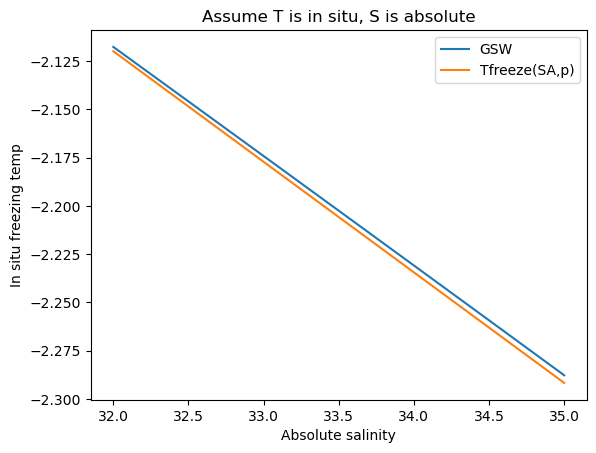

In [5]:
plt.plot(SA,t_freezing, label = 'GSW')
plt.plot(SA,Tfreeze(SA,p), label = 'Tfreeze(SA,p)')
plt.ylabel('In situ freezing temp')
plt.xlabel('Absolute salinity')
plt.title('Assume T is in situ, S is absolute')
plt.legend()

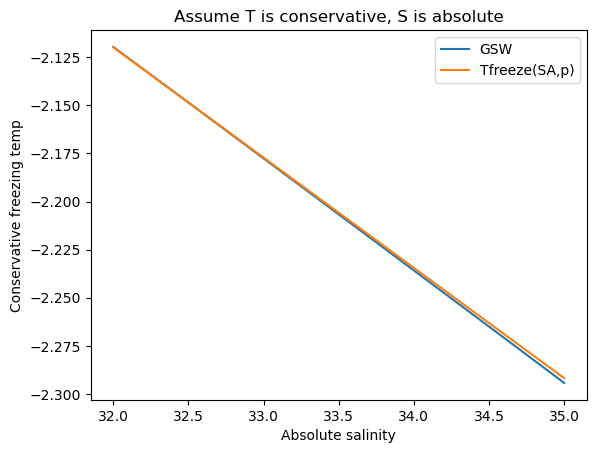

In [6]:
plt.plot(SA,CT_freezing, label = 'GSW')
plt.plot(SA,Tfreeze(SA,p), label = 'Tfreeze(SA,p)')
plt.ylabel('Conservative freezing temp')
plt.xlabel('Absolute salinity')
plt.title('Assume T is conservative, S is absolute')

plt.legend()

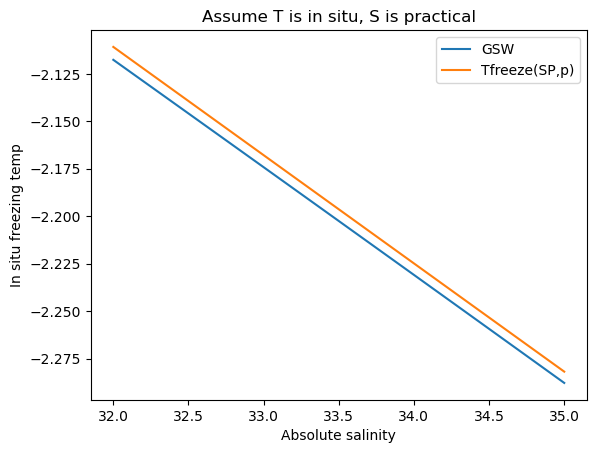

In [7]:
plt.plot(SA,t_freezing, label = 'GSW')
plt.plot(SA,Tfreeze(SP,p), label = 'Tfreeze(SP,p)')
plt.ylabel('In situ freezing temp')
plt.xlabel('Absolute salinity')
plt.title('Assume T is in situ, S is practical')

plt.legend()

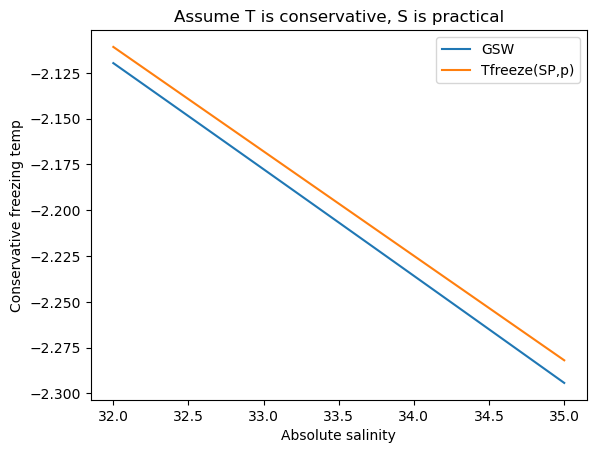

In [8]:
plt.plot(SA,CT_freezing, label = 'GSW')
plt.plot(SA,Tfreeze(SP,p), label = 'Tfreeze(SP,p)')
plt.ylabel('Conservative freezing temp')
plt.xlabel('Absolute salinity')
plt.title('Assume T is conservative, S is practical')
plt.legend()

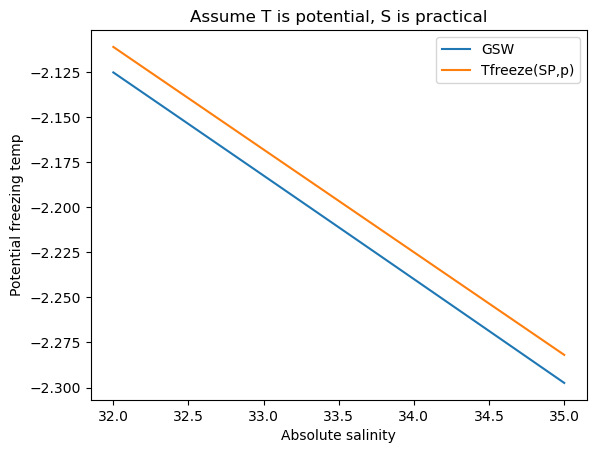

In [9]:
pt_freezing = gsw.pt_from_CT(SA, CT_freezing)
plt.plot(SA,pt_freezing, label = 'GSW')
plt.plot(SA,Tfreeze(SP,p), label = 'Tfreeze(SP,p)')
plt.ylabel('Potential freezing temp')
plt.xlabel('Absolute salinity')
plt.title('Assume T is potential, S is practical')

plt.legend()

# Explore a larger regime space

/jobfs/144301768.gadi-pbs/ipykernel_4102801/4111622063.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c= axes[2].pcolormesh(SPs,ps,CT_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
/jobfs/144301768.gadi-pbs/ipykernel_4102801/4111622063.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  d= axes[3].pcolormesh(SPs,ps,t_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)


Text(0.5, 1.08, 'Difference in freezing temp at each p, S where p in linear EOS does include atmos pressure')

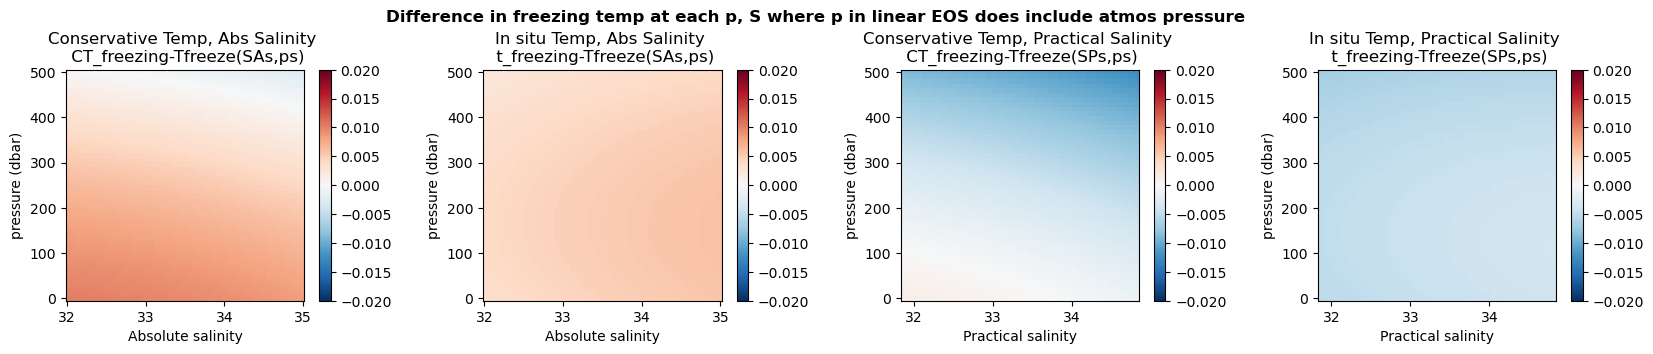

In [10]:
#linear EOS
def Tfreeze(S,p): # -> not sure what temp units are
    lam_1 = -0.0573 #Ckg/g (salinity) -> not sure what units are 
    lam_2 = -7.53e-4 #C/dbar (pressure)
    lam_3 = 0.0826 # offset
    return lam_3+lam_1*S+lam_2*(p-10.13) #dbar offset in gsw pressures

SAs, ps = np.meshgrid(SA,np.linspace(0,500))

t_freezing = gsw.t_freezing(SAs,ps,0)
CT_freezing = gsw.CT_freezing(SAs,ps,0)
SPs = gsw.SP_from_SA(SAs, ps, 0, -65)
fig,axes = plt.subplots(figsize = (20,3),ncols = 4)

a= axes[0].pcolormesh(SAs,ps,CT_freezing-Tfreeze(SAs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
axes[0].set_title('Conservative Temp, Abs Salinity \n CT_freezing-Tfreeze(SAs,ps)')
plt.colorbar(a,ax = axes[0])
axes[0].set_ylabel('pressure (dbar)')
axes[0].set_xlabel('Absolute salinity')

b= axes[1].pcolormesh(SAs,ps,t_freezing-Tfreeze(SAs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
axes[1].set_title('In situ Temp, Abs Salinity \n t_freezing-Tfreeze(SAs,ps)')
plt.colorbar(a,ax = axes[1])
axes[1].set_ylabel('pressure (dbar)')
axes[1].set_xlabel('Absolute salinity')

c= axes[2].pcolormesh(SPs,ps,CT_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
axes[2].set_title('Conservative Temp, Practical Salinity \n CT_freezing-Tfreeze(SPs,ps)')
plt.colorbar(a,ax = axes[2])
axes[2].set_ylabel('pressure (dbar)')
axes[2].set_xlabel('Practical salinity')

d= axes[3].pcolormesh(SPs,ps,t_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
axes[3].set_title('In situ Temp, Practical Salinity \n t_freezing-Tfreeze(SPs,ps)')
plt.colorbar(a,ax = axes[3])
axes[3].set_ylabel('pressure (dbar)')
axes[3].set_xlabel('Practical salinity')

fig.subplots_adjust(wspace = 0.4)
fig.suptitle('Difference in freezing temp at each p, S where p in linear EOS does include atmos pressure', y = 1.08, fontweight = 'bold')

/jobfs/144301768.gadi-pbs/ipykernel_4102801/2859164034.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c= axes[2].pcolormesh(SPs,ps,CT_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r',vmax=0.02, vmin = -0.02)
/jobfs/144301768.gadi-pbs/ipykernel_4102801/2859164034.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  d= axes[3].pcolormesh(SPs,ps,t_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)


Text(0.5, 1.08, 'Difference in freezing temp at each p, S where p in linear EOS doesnt include atmos pressure')

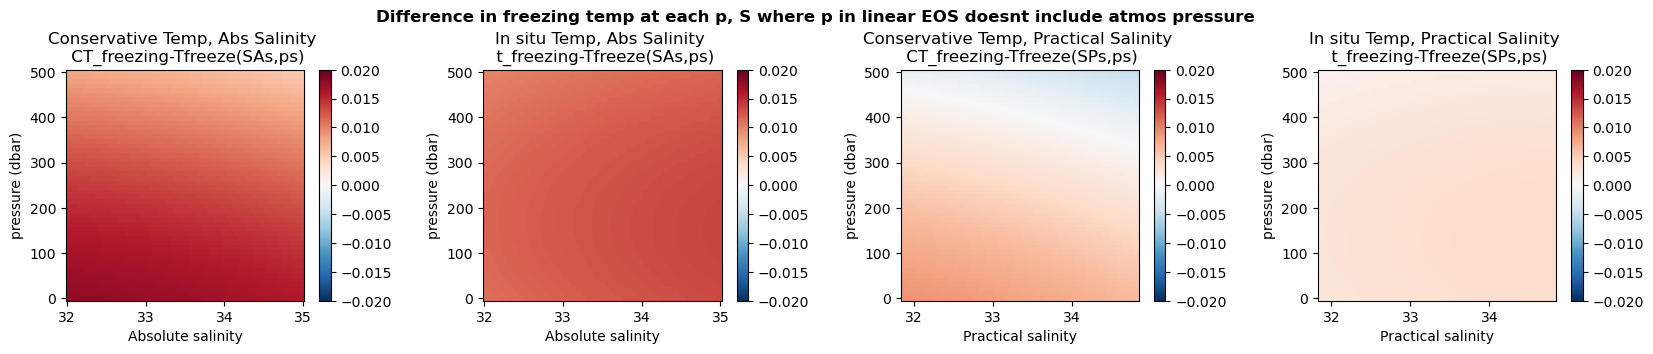

In [11]:
#linear EOS
def Tfreeze(S,p): # -> not sure what temp units are
    lam_1 = -0.0573 #Ckg/g (salinity) -> not sure what units are 
    lam_2 = -7.53e-4 #C/dbar (pressure)
    lam_3 = 0.0826 # offset
    return lam_3+lam_1*S+lam_2*(p)#-10.13) #dbar offset in gsw pressures

SAs, ps = np.meshgrid(SA,np.linspace(0,500))

t_freezing = gsw.t_freezing(SAs,ps,0)
CT_freezing = gsw.CT_freezing(SAs,ps,0)
SPs = gsw.SP_from_SA(SAs, ps, 0, -65)

fig,axes = plt.subplots(figsize = (20,3),ncols = 4)

a= axes[0].pcolormesh(SAs,ps,CT_freezing-Tfreeze(SAs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
axes[0].set_title('Conservative Temp, Abs Salinity \n CT_freezing-Tfreeze(SAs,ps)')
plt.colorbar(a,ax = axes[0])
axes[0].set_ylabel('pressure (dbar)')
axes[0].set_xlabel('Absolute salinity')

b= axes[1].pcolormesh(SAs,ps,t_freezing-Tfreeze(SAs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
axes[1].set_title('In situ Temp, Abs Salinity \n t_freezing-Tfreeze(SAs,ps)')
plt.colorbar(a,ax = axes[1])
axes[1].set_ylabel('pressure (dbar)')
axes[1].set_xlabel('Absolute salinity')

c= axes[2].pcolormesh(SPs,ps,CT_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r',vmax=0.02, vmin = -0.02)
axes[2].set_title('Conservative Temp, Practical Salinity \n CT_freezing-Tfreeze(SPs,ps)')
plt.colorbar(a,ax = axes[2])
axes[2].set_ylabel('pressure (dbar)')
axes[2].set_xlabel('Practical salinity')

d= axes[3].pcolormesh(SPs,ps,t_freezing-Tfreeze(SPs,ps),cmap = 'RdBu_r', vmax=0.02, vmin = -0.02)
axes[3].set_title('In situ Temp, Practical Salinity \n t_freezing-Tfreeze(SPs,ps)')
plt.colorbar(a,ax = axes[3])
axes[3].set_ylabel('pressure (dbar)')
axes[3].set_xlabel('Practical salinity')

fig.subplots_adjust(wspace = 0.4)
fig.suptitle('Difference in freezing temp at each p, S where p in linear EOS doesnt include atmos pressure', y = 1.08, fontweight = 'bold')
